In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Limpieza de datos

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
# cargar el dataset
df = pd.read_csv('clientes_shopping.csv')

# Comprobación de valores nulos
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

# Duplicados
print("\n--- Cantidad de duplicados ---")
print(df.duplicated().sum())

# Estadísticas descriptivas
print("\n--- Estadísticas descriptivas ---")
display(df.describe())




--- Valores nulos por columna ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Cantidad de duplicados ---
0

--- Estadísticas descriptivas ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


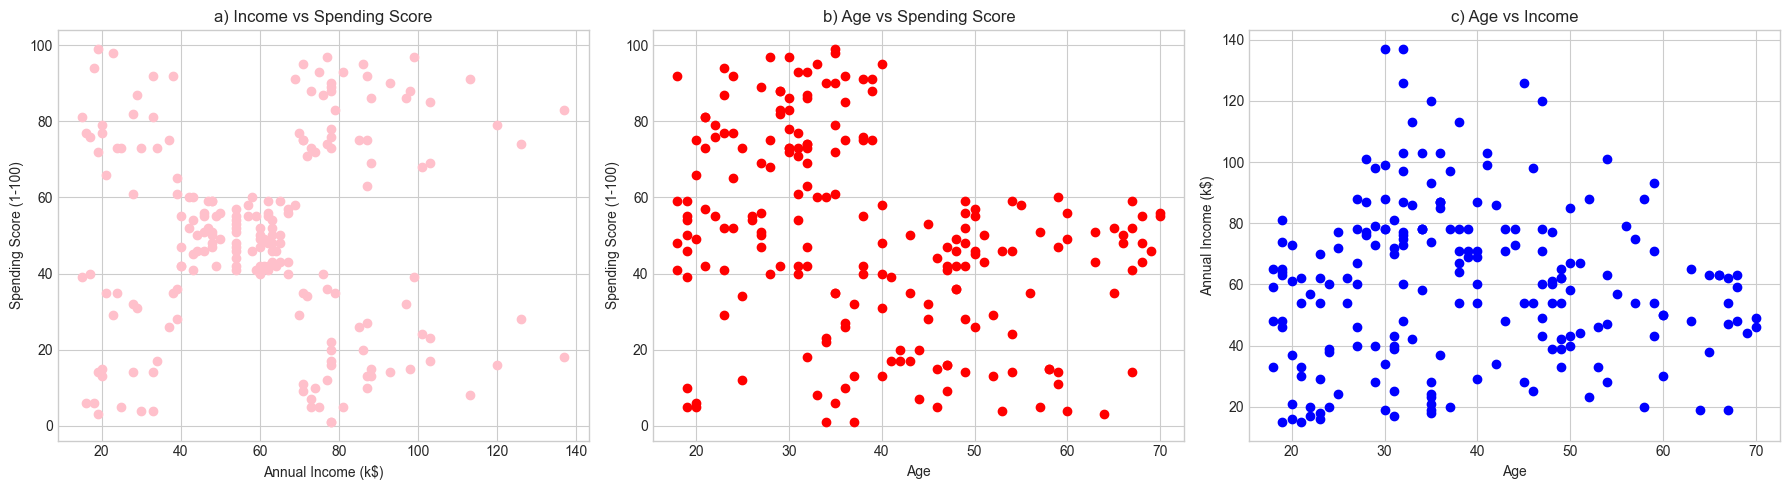

In [ ]:

# Seleccionar variables numéricas relevantes
X= df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#graficos de dispersion
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='pink')
axes[0].set_title('a) Income vs Spending Score')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

axes[1].scatter(df['Age'], df['Spending Score (1-100)'], color='red')
axes[1].set_title('b) Age vs Spending Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')

axes[2].scatter(df['Age'], df['Annual Income (k$)'], color='blue')
axes[2].set_title('c) Age vs Income')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')

plt.tight_layout()
plt.show()


# Determinar número óptimo de clusters

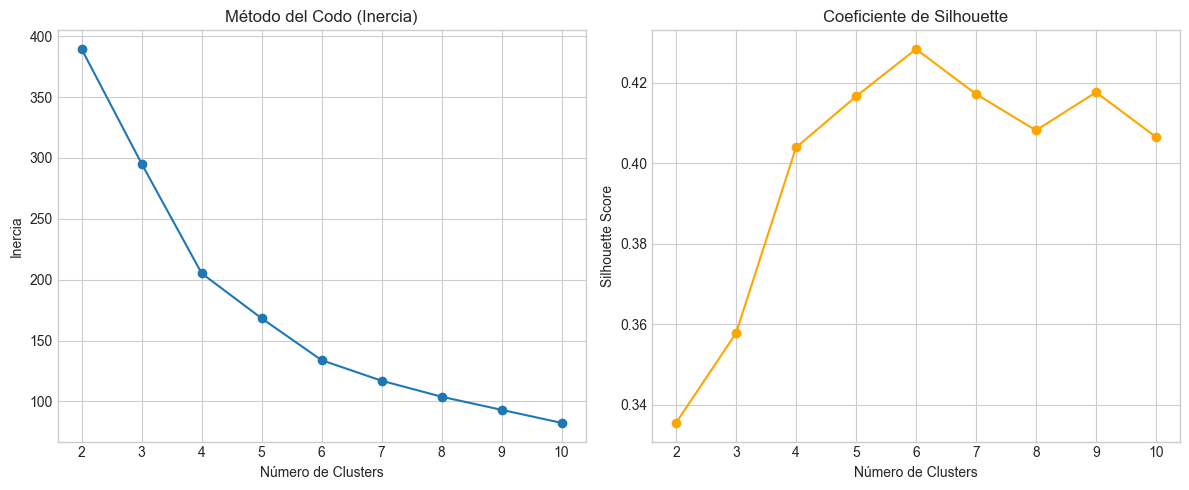

In [4]:
inertias = []
silhouettes = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

plt.subplot(1,2,2)
plt.plot(range(2,11), silhouettes, marker='o', color='orange')
plt.title('Coeficiente de Silhouette')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


# Aplicar modelo K-Means con un k óptimo

In [5]:
k_opt = 5 # Determinado a partir de los gráficos anteriores
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


# Graficos con clusters

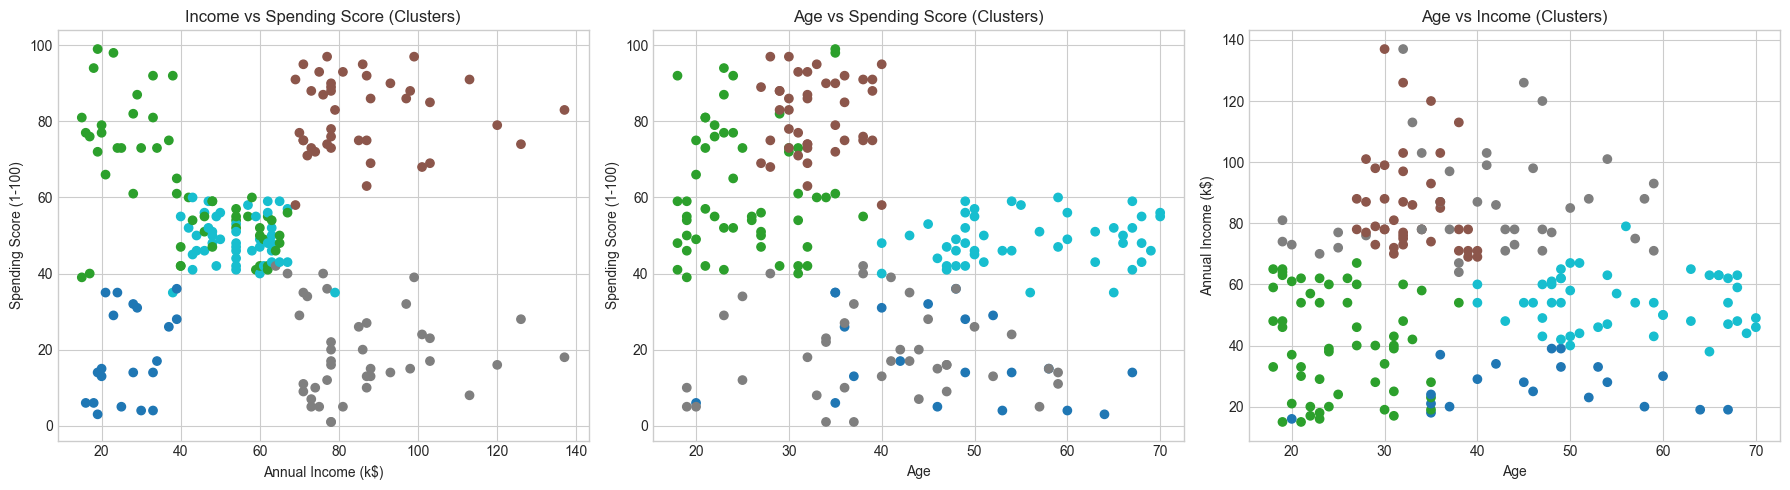

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='tab10')
axes[0].set_title('Income vs Spending Score (Clusters)')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

axes[1].scatter(df['Age'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='tab10')
axes[1].set_title('Age vs Spending Score (Clusters)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')

axes[2].scatter(df['Age'], df['Annual Income (k$)'], c=df['Cluster'], cmap='tab10')
axes[2].set_title('Age vs Income (Clusters)')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')

plt.tight_layout()
plt.show()


# Analisis de los grupos

In [8]:
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
display(summary)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85
